In [1]:
import numpy as np

In [20]:
import matplotlib.pyplot as plt

In [21]:
import scipy

In [11]:
data1 = np.loadtxt('Daten_Frage_A.dat', delimiter='|')

In [12]:
data1.shape

(2001, 2)

In [15]:
data1[-1, 0] - data1[0, 0]

np.float64(200.0)

In [16]:
np.max(data1[:, 1])

np.float64(0.21990735817072385)

In [17]:
np.mean(data1[:, 1])

np.float64(0.1198835386926476)

In [18]:
np.std(data1[:, 1])

np.float64(0.025333204570220483)

In [19]:
dataB2 = np.loadtxt('Daten_Frage_B2.txt', delimiter=',')

In [151]:
np.mean(dataB2[:, 1])

np.float64(25.05571696645)

In [31]:
scipy.stats.moment(dataB2[:, 1], order=[1, 2, 3])

array([0.        , 9.11118776, 4.63271028])

(array([2.500e+01, 2.550e+02, 1.265e+03, 2.639e+03, 3.064e+03, 1.866e+03,
        6.880e+02, 1.780e+02, 1.700e+01, 3.000e+00]),
 array([14.7305214 , 17.14452181, 19.55852222, 21.97252263, 24.38652304,
        26.80052345, 29.21452386, 31.62852427, 34.04252468, 36.45652509,
        38.8705255 ]),
 <BarContainer object of 10 artists>)

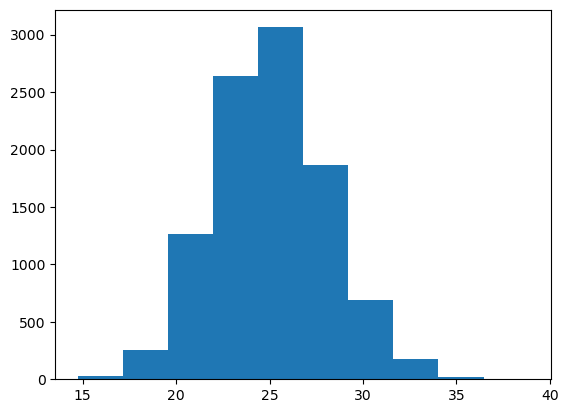

In [34]:
plt.hist(dataB2[:, 1])

In [39]:
dataC1 = np.loadtxt('Daten_Frage_C1.txt', delimiter='	')

In [40]:
dataC1

array([[ 0.00000000e+00, -1.73920288e-03],
       [ 1.00000000e-01, -2.06884554e-03],
       [ 2.00000000e-01, -1.55700664e-03],
       ...,
       [ 1.49800000e+02,  1.21390089e-03],
       [ 1.49900000e+02,  5.47246426e-03],
       [ 1.50000000e+02, -3.50516802e-03]], shape=(1501, 2))

In [41]:
np.std(dataC1[:, 1])

np.float64(0.003321348866250454)

In [45]:
spectrum = np.fft.fft(dataC1[:, 1])

In [46]:
spectrum

array([ 0.03990891+0.j        , -0.03937294-0.05853982j,
        0.04303552+0.04840145j, ...,  0.01847439-0.13066561j,
        0.04303552-0.04840145j, -0.03937294+0.05853982j], shape=(1501,))

In [49]:
delta_t = dataC1[1, 0] - dataC1[0, 0]

In [50]:
delta_t

np.float64(0.1)

In [51]:
np.argmax(spectrum)

np.int64(614)

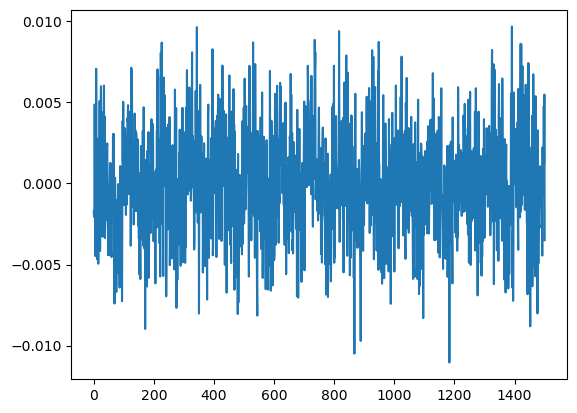

In [54]:
plt.plot(dataC1[:, 1])

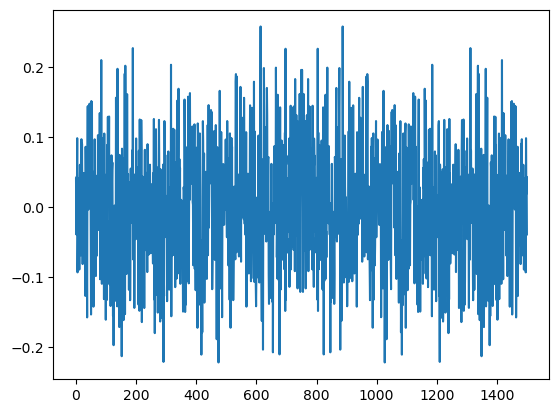

In [55]:
plt.plot(spectrum)

In [56]:
spectrum.shape

(1501,)

In [57]:
750 - 614

136

In [147]:
data_new = [np.sum(dataC1[k:k+30, 1] / 30) for k in range(0, dataC1.shape[0] - 30)]

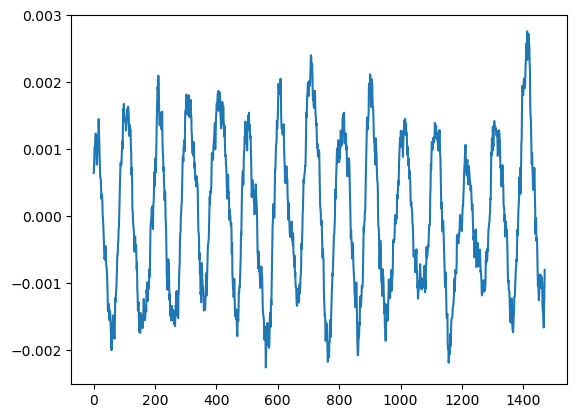

In [148]:
plt.plot(data_new)

In [149]:
np.std(data_new)

np.float64(0.0011307284903948852)

In [58]:
dataD2 = np.loadtxt('Daten_Frage_D2.txt', delimiter='	')

In [60]:
np.mean(dataD2[:, 1])

np.float64(1.6001863590039571)

In [61]:
np.var(dataD2[:, 1])

np.float64(0.007230846480334927)

In [62]:
np.mean(dataD2[:, 2])

np.float64(0.8057916862954384)

In [63]:
np.var(dataD2[:, 2])

np.float64(0.014727704505713372)

In [64]:
np.sqrt(1e-11)

np.float64(3.162277660168379e-06)

In [65]:
dataH1 = np.loadtxt('Daten_Frage_H1.txt', delimiter=',', skiprows=1)

In [66]:
dataH1

array([[ 0.4      , 12.6083601,  0.3290139],
       [ 0.6421053,  7.9983487,  0.2285806],
       [ 0.8842105,  6.1987431,  0.305091 ],
       [ 1.1263158,  5.1178511,  0.2761568],
       [ 1.3684211,  4.5460871,  0.2808894],
       [ 1.6105263,  4.5007305,  0.1821994],
       [ 1.8526316,  4.3437537,  0.2978192],
       [ 2.0947368,  4.5455007,  0.2955339],
       [ 2.3368421,  4.969669 ,  0.2131582],
       [ 2.5789474,  5.3155673,  0.1943762],
       [ 2.8210526,  5.9499647,  0.3898855],
       [ 3.0631579,  6.3198827,  0.1851989],
       [ 3.3052632,  6.9863962,  0.3091957],
       [ 3.5473684,  7.6922714,  0.326896 ],
       [ 3.7894737,  8.4798059,  0.3226663],
       [ 4.0315789,  9.2837716,  0.1788238],
       [ 4.2736842, 10.2258616,  0.3165271],
       [ 4.5157895, 11.262463 ,  0.2541615],
       [ 4.7578947, 12.4279132,  0.3070207],
       [ 5.       , 13.5574176,  0.2610324]])

In [67]:
def poly_fit(x, y, y_sigma, deg=1):
    m = deg + 1
    N = np.zeros((m, m))
    Y = np.zeros(m)

    for i in range(m): 
        for j in range(m):
            N[i, j] = np.sum([np.pow(x[k], i + j) / np.square(sigma) for k, sigma in enumerate(y_sigma)])

    for i in range(m):
        Y[i] = np.sum([np.pow(x[k], i) * y[k] / np.square(sigma) for k, sigma in enumerate(y_sigma)])

    return np.linalg.inv(N) @ Y


In [68]:
x = dataH1[:,0]

In [69]:
y = dataH1[:,1]

In [70]:
y_sigma = dataH1[:,2]

In [71]:
poly_fit(x, y, y_sigma, deg=3)

array([ 14.54435323, -11.76103183,   3.98920742,  -0.33984843])

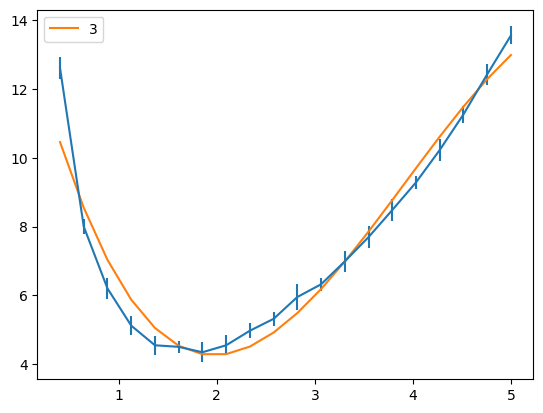

In [76]:
fig, ax = plt.subplots()
ax.errorbar(x, y, yerr=y_sigma)

for deg in range(3, 4):
    a = poly_fit(x, y, y_sigma, deg)
    ax.plot(x, np.sum([a_k * np.power(x, k) for k, a_k in enumerate(a)], axis=0), label=deg)

ax.legend()

In [92]:
# Task 1: Read the data from data.csv

# Hint: This one we already solved for you ;)
import pandas as pd
import numpy as np

df = pd.read_csv("data.csv")

X = df.drop(['target'], axis=1)
y = df['target']

# Task 2: Split data into training and testing.

from sklearn.model_selection import train_test_split

# Hint: this function takes as parameter X, y, and a 'test_size' ;)
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8)

# Task 3: Train a model on your data.

# Hint 1: Below are some options for models ;)
# Hint 2: To train a model, use the method 'fit' with some X and some y.
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier

model = LogisticRegression(max_iter=100)
model.fit(X_train, y_train)

# Task 4: Measure the quality of your estimator in the test data.

from sklearn.metrics import accuracy_score

# Hint: Here you use your estimator to 'predict' the labels for your
# test data.
y_pred = model.predict(X_test)

print(accuracy_score(y_pred, y_test))

# Hint: Call accuracy_score with the following arguments:
# 1. the true labels.
# 2. the labels you predicted.
acc = 0.

# print("Accuracy of classif. tree on test data: {:.3f}".format(acc))

# Task 5: Use your estimator to make predictions for the examples in X_final.csv

X_final = pd.read_csv("X_final.csv")
y_final = model.predict(X_final)
print(y_final)


1.0
[2 1 2 1 1 1 0 2 0 1]


In [102]:
df = pd.read_csv('coincidence_two_detectors.csv')
df.head()



,timestamp,top_counts,bottom_counts
0,0.0,7,10
1,0.5,11,11
2,1.0,5,5
3,1.5,8,10
4,2.0,10,5


In [96]:
dataX

array([nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, na

In [107]:
timestamp = np.array(df['timestamp'])
top = np.array(df['top_counts'])
bot = np.array(df['bottom_counts'])

In [115]:
timestamp

array([  0. ,   0.5,   1. ,   1.5,   2. ,   2.5,   3. ,   3.5,   4. ,
         4.5,   5. ,   5.5,   6. ,   6.5,   7. ,   7.5,   8. ,   8.5,
         9. ,   9.5,  10. ,  10.5,  11. ,  11.5,  12. ,  12.5,  13. ,
        13.5,  14. ,  14.5,  15. ,  15.5,  16. ,  16.5,  17. ,  17.5,
        18. ,  18.5,  19. ,  19.5,  20. ,  20.5,  21. ,  21.5,  22. ,
        22.5,  23. ,  23.5,  24. ,  24.5,  25. ,  25.5,  26. ,  26.5,
        27. ,  27.5,  28. ,  28.5,  29. ,  29.5,  30. ,  30.5,  31. ,
        31.5,  32. ,  32.5,  33. ,  33.5,  34. ,  34.5,  35. ,  35.5,
        36. ,  36.5,  37. ,  37.5,  38. ,  38.5,  39. ,  39.5,  40. ,
        40.5,  41. ,  41.5,  42. ,  42.5,  43. ,  43.5,  44. ,  44.5,
        45. ,  45.5,  46. ,  46.5,  47. ,  47.5,  48. ,  48.5,  49. ,
        49.5,  50. ,  50.5,  51. ,  51.5,  52. ,  52.5,  53. ,  53.5,
        54. ,  54.5,  55. ,  55.5,  56. ,  56.5,  57. ,  57.5,  58. ,
        58.5,  59. ,  59.5,  60. ,  60.5,  61. ,  61.5,  62. ,  62.5,
        63. ,  63.5,

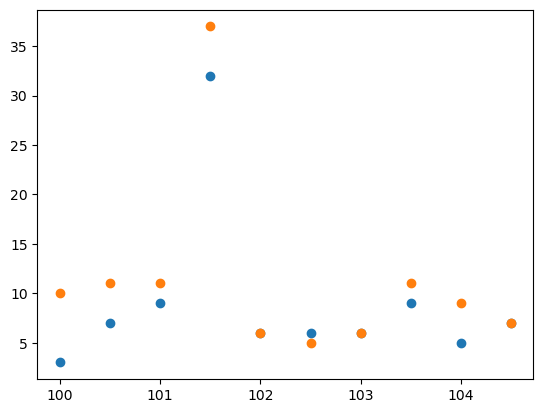

In [138]:
k = 200
l = 10

plt.scatter(timestamp[k:k+l], top[k:k+l])
plt.scatter(timestamp[k:k+l], bot[k:k+l])

In [150]:
timestamp[214]

np.float64(107.0)